In [12]:
import xarray as xr

ds = xr.open_dataset("data_pipeline/data/raw/glorys/Down/glorys_thetao_2000_01.nc")

ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 31, depth: 35, latitude: 301, longitude: 721)
Coordinates:
  * time       (time) datetime64[ns] 248B 2000-01-01 2000-01-02 ... 2000-01-31
  * depth      (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
  * latitude   (latitude) float32 1kB 5.0 5.083 5.167 5.25 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 3kB 45.0 45.08 45.17 ... 104.8 104.9 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 2GB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

In [13]:
ds.depth.values

array([4.940250e-01, 1.541375e+00, 2.645669e+00, 3.819495e+00,
       5.078224e+00, 6.440614e+00, 7.929560e+00, 9.572997e+00,
       1.140500e+01, 1.346714e+01, 1.581007e+01, 1.849556e+01,
       2.159882e+01, 2.521141e+01, 2.944473e+01, 3.443415e+01,
       4.034405e+01, 4.737369e+01, 5.576429e+01, 6.580727e+01,
       7.785385e+01, 9.232607e+01, 1.097293e+02, 1.306660e+02,
       1.558507e+02, 1.861256e+02, 2.224752e+02, 2.660403e+02,
       3.181274e+02, 3.802130e+02, 4.539377e+02, 5.410889e+02,
       6.435668e+02, 7.633331e+02, 9.023393e+02], dtype=float32)

In [26]:
import numpy as np

target_lat = np.arange(5.0, 30.0, 0.25)
target_lon = np.arange(45.0, 105.0, 0.25)
target_depths = [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]

# Interpolate spatially and vertically
ds_standardized = ds.interp(
    latitude=target_lat,
    longitude=target_lon,
    depth=target_depths,
    method="linear",
    kwargs={"fill_value": "extrapolate"}
)
'''
ds_standardized = ds.interp(
    latitude=target_lat,
    longitude=target_lon,
    depth=target_depths,
    method="linear" 
).astype(np.float32)
'''

'\nds_standardized = ds.interp(\n    latitude=target_lat,\n    longitude=target_lon,\n    depth=target_depths,\n    method="linear" \n).astype(np.float32)\n'

In [27]:
ds_standardized

<xarray.Dataset> Size: 89MB
Dimensions:    (time: 31, depth: 15, latitude: 100, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 248B 2000-01-01 2000-01-02 ... 2000-01-31
  * depth      (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
  * latitude   (latitude) float64 800B 5.0 5.25 5.5 5.75 ... 29.25 29.5 29.75
  * longitude  (longitude) float64 2kB 45.0 45.25 45.5 ... 104.2 104.5 104.8
Data variables:
    thetao     (time, depth, latitude, longitude) float64 89MB nan nan ... nan
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

In [28]:
output_filename = "data_pipeline/data/raw/glorys/Target/processed_target_jan_2023.nc"

ds_standardized.to_netcdf(output_filename)

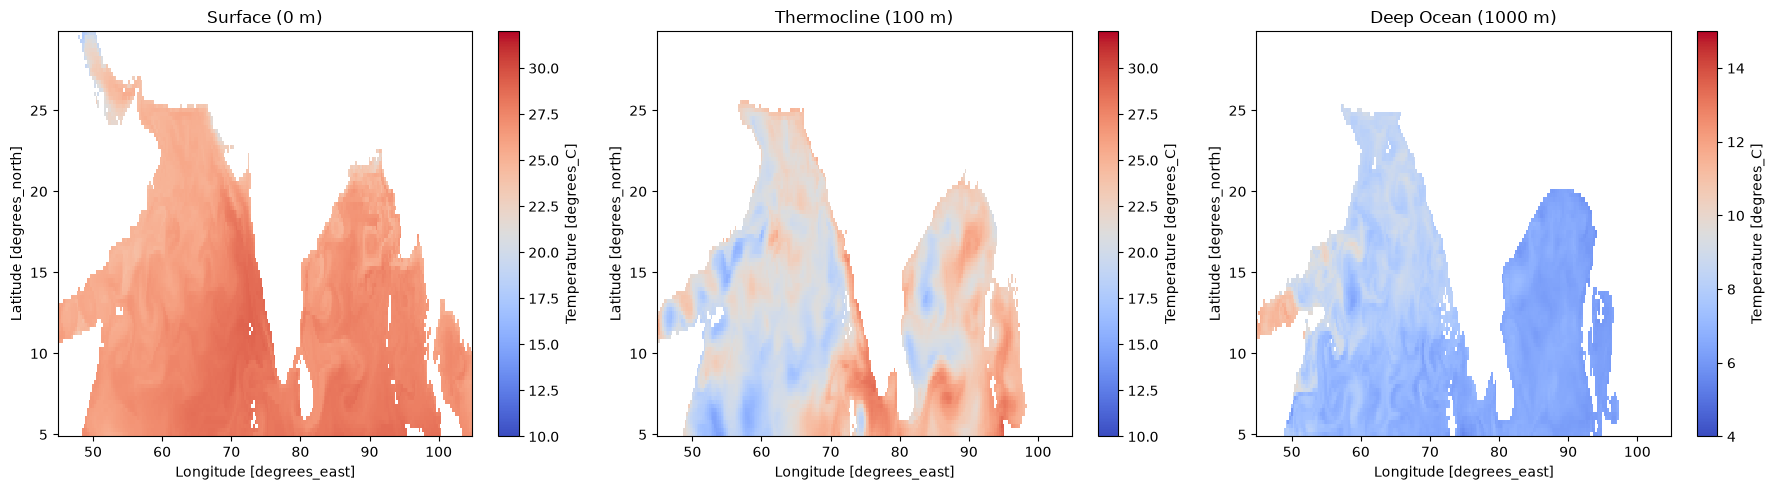

In [29]:
# Visual validation
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Day 0 at surface (0m), 100m (thermocline), and 1000m (deep ocean)
ds_standardized['thetao'].isel(time=0).sel(depth=0).plot(ax=axes[0], cmap="coolwarm", vmin=10, vmax=32)
axes[0].set_title("Surface (0 m)")

ds_standardized['thetao'].isel(time=0).sel(depth=100).plot(ax=axes[1], cmap="coolwarm", vmin=10, vmax=32)
axes[1].set_title("Thermocline (100 m)")

ds_standardized['thetao'].isel(time=0).sel(depth=1000).plot(ax=axes[2], cmap="coolwarm", vmin=4, vmax=15)
axes[2].set_title("Deep Ocean (1000 m)")

plt.tight_layout()
plt.show()

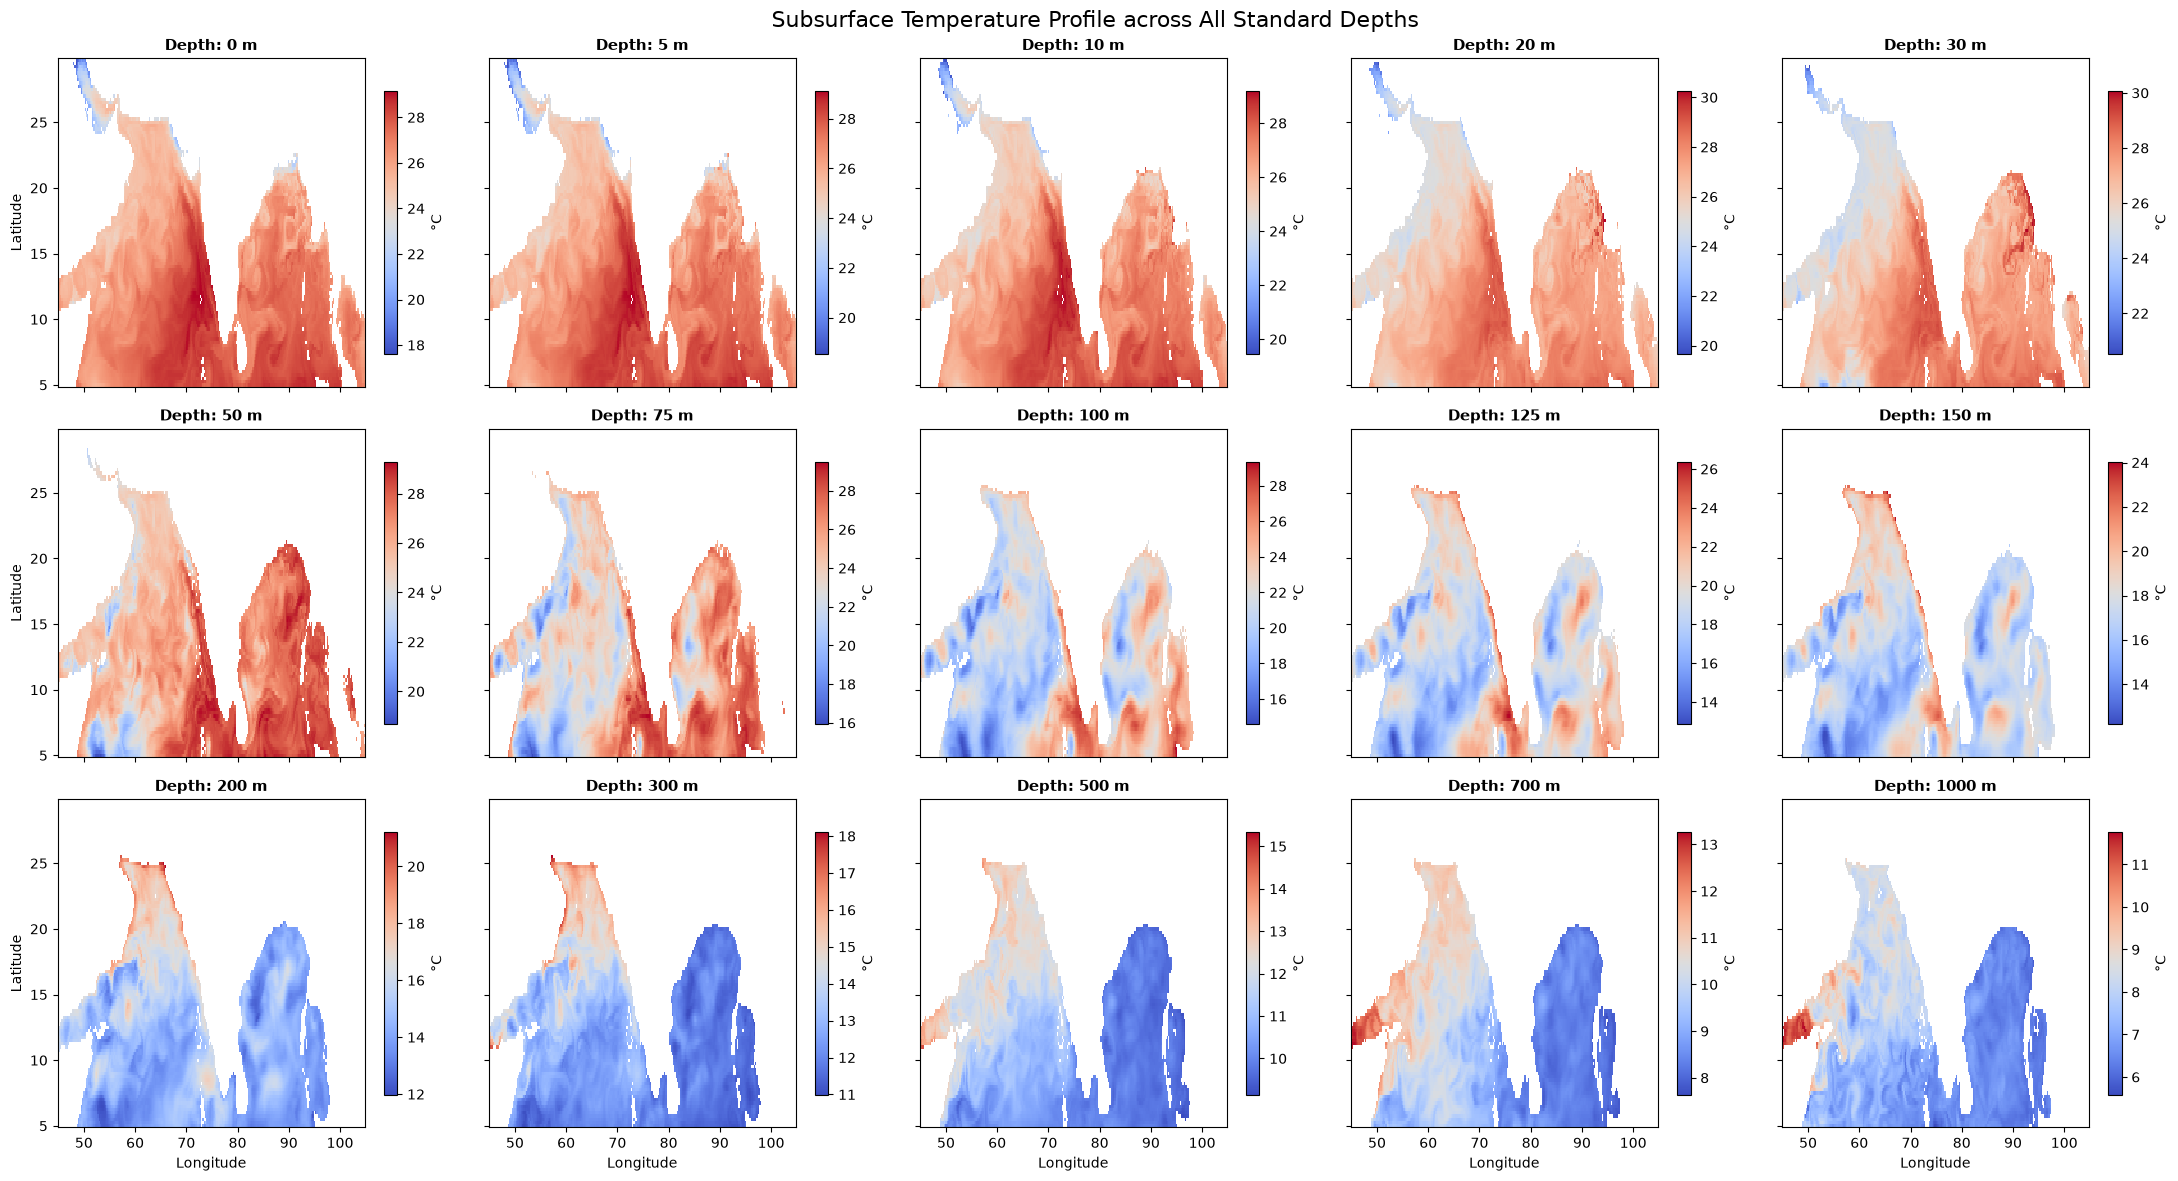

In [30]:
import matplotlib.pyplot as plt

# Define target depths
target_depths = [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]

#  Setup a 3x5
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(22, 12), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten 2D array of axes into a 1D list for easy iteration

for idx, depth in enumerate(target_depths):
    ax = axes[idx]
    
    # Extract depth slice for the first day
    depth_slice = ds_standardized['thetao'].isel(time=0).sel(depth=depth)
    
    p = depth_slice.plot(
        ax=ax,
        cmap="coolwarm",
        add_colorbar=True,
        cbar_kwargs={"shrink": 0.8, "label": "°C"}
    )
    
    ax.set_title(f"Depth: {depth} m", fontsize=11, fontweight="bold")
    ax.set_xlabel("Longitude" if idx >= 10 else "")
    ax.set_ylabel("Latitude" if idx % 5 == 0 else "")

plt.suptitle("Subsurface Temperature Profile across All Standard Depths", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()